# Crypto Perpetuals: Current Strategy Analysis

This capstone binds the corrected v3.1 model, backtest, and cohort lineage for the 24-hour return
label. It records the validation-selected carrier and its single authorized holdout result.

**Learning objectives**

- compare the current 24-hour model families on a common decision-time panel;
- distinguish predictive IC leadership from strategy-level carrier selection;
- interpret validation Sharpe together with selection-adjusted uncertainty;
- interpret the fixed carrier's validation-to-holdout deterioration without reselection.

**Book reference**: Chapter 20, strategy synthesis and evidence handoff.

**Prerequisites**: the signed current 24-hour linear and GBM producers and completed validation
baseline, allocation, cost, risk, and cohort surfaces.

**Scope**: the executed cells preserve the deterministic pre-holdout selection record. The final
publication cell reports the signed one-shot holdout evidence without training, reselection,
registry mutation, or another backtest.

In [1]:
"""Read-only synthesis of the current Crypto 24-hour validation carrier."""

import hashlib
import json
import sqlite3
import subprocess
from datetime import datetime

import plotly.graph_objects as go
import polars as pl
import yaml
from IPython.display import Markdown, display
from ml4t.diagnostic.metrics import compute_ic_uncertainty

from utils.paths import REPO_ROOT, get_case_study_dir, get_case_study_source_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
CASE_STUDY = "crypto_perps_funding"
PRIMARY_LABEL = "fwd_ret_24h"
LABEL_HORIZON_HOURS = 24
SEED = 42

In [3]:
SURFACE_POLICY = "current_v31_only"
INPUT_FINGERPRINT = "4288331d8f6a21a516a293d06ae805e8f599a1d1d2af17d3f98ddac8a3b005fa"
EXPECTED_CURRENT_MD5 = "465f1cff82be197ea55b6e1e0145d3cf"
EXPECTED_CURRENT_COUNTS = {
    "training_runs": 91,
    "prediction_sets": 138,
    "backtest_runs": 698,
    "cohort_metrics": 23,
}
EXPECTED_PRODUCER_BLOBS = {
    "06_linear.py": "c1343570c423283334c633a9f220b98c4e65d294",
    "06_linear.ipynb": "5744f22ca3718576f19d7611575b8c06db70d166",
    "07_gbm.py": "4cc22e580706f794c915b31a7593ddc63d980059",
    "07_gbm.ipynb": "7891203023e3ee413258b3e2c528da8e94f71f98",
}
EXPECTED_LEADERS = {
    "gbm": ("leaves_7_mae", "491ea02ecf58", None),
    "linear": ("ridge_a100.0", "3cbcb5c8a9dc", None),
}
EXPECTED_CARRIER = {
    "backtest_hash": "e56dd4ed5e10",
    "prediction_hash": "53599526d2aa",
    "family": "linear",
    "config_name": "ridge_a10.0",
    "stage": "risk_overlay",
}

In [4]:
set_global_seeds(SEED)
CURRENT_CASE_DIR = get_case_study_dir(CASE_STUDY, create=False)
SOURCE_CASE_DIR = get_case_study_source_dir(CASE_STUDY)
CURRENT_REGISTRY = CURRENT_CASE_DIR / "run_log" / "registry.db"
PREDICTION_DIR = CURRENT_CASE_DIR / "run_log" / "predictions"
setup = yaml.safe_load((SOURCE_CASE_DIR / "config" / "setup.yaml").read_text())
HOLDOUT_START = datetime.fromisoformat(setup["evaluation"]["holdout_start"])

## Bind the completed pre-holdout surface

The executed record below fixed the producer identities, registry counts, and empty holdout before
evaluation. Every SQLite connection was read-only. The final publication cell preserves this
chronology instead of rerunning these pre-holdout checks against the post-evaluation registry.

In [5]:
def _md5(path) -> str:
    """Return an artifact identity digest without opening the file for mutation."""
    digest = hashlib.md5(usedforsecurity=False)
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

In [6]:
def _git_blob(name: str) -> str:
    """Return the committed Git blob for one current producer file."""
    path = f"case_studies/{CASE_STUDY}/{name}"
    # -c safe.directory trusts this checkout for this one invocation: CI containers mount the
    # workspace with a different owner than the container user, which makes bare `git` refuse to
    # run ("detected dubious ownership") even though the checkout itself is exactly what the test
    # is running from.
    return subprocess.check_output(
        ["git", "-c", f"safe.directory={REPO_ROOT}", "rev-parse", f"HEAD:{path}"],
        cwd=REPO_ROOT,
        text=True,
    ).strip()

In [7]:
def _registry_boundary(path) -> tuple[dict[str, int], dict[str, int]]:
    """Return current table counts and holdout counts."""
    with sqlite3.connect(f"file:{path}?mode=ro", uri=True) as connection:
        counts = {
            table: int(connection.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0])
            for table in EXPECTED_CURRENT_COUNTS
        }
        holdout = {
            "predictions": int(
                connection.execute(
                    "SELECT COUNT(*) FROM prediction_sets WHERE split = 'holdout'"
                ).fetchone()[0]
            ),
            "backtests": int(
                connection.execute(
                    "SELECT COUNT(*) FROM backtest_runs br JOIN prediction_sets ps "
                    "USING (prediction_hash) WHERE ps.split = 'holdout'"
                ).fetchone()[0]
            ),
        }
    return counts, holdout

In [8]:
actual_producer_blobs = {name: _git_blob(name) for name in EXPECTED_PRODUCER_BLOBS}
if actual_producer_blobs != EXPECTED_PRODUCER_BLOBS:
    raise RuntimeError("A signed 24-hour producer changed")

current_md5_before = _md5(CURRENT_REGISTRY)
if current_md5_before != EXPECTED_CURRENT_MD5:
    raise RuntimeError("The current registry changed before strategy synthesis")

current_counts, holdout_counts = _registry_boundary(CURRENT_REGISTRY)
if current_counts != EXPECTED_CURRENT_COUNTS:
    raise RuntimeError(f"Current surface changed: {current_counts}")
if holdout_counts != {"predictions": 0, "backtests": 0}:
    raise RuntimeError(f"Holdout was accessed before carrier freeze: {holdout_counts}")

print(f"Current surface: {current_counts}")
print("Holdout remains sealed: 0 predictions, 0 backtests")
print("Signed 24-hour producer identities and current registry digest pass")

Current surface: {'training_runs': 91, 'prediction_sets': 138, 'backtest_runs': 698, 'cohort_metrics': 23}
Holdout remains sealed: 0 predictions, 0 backtests
Signed 24-hour producer identities and current registry digest pass


## Compare the current 24-hour model leaders

Complete validation predictions are aligned on common timestamp-symbol keys. The chart recomputes
decision-time rank IC and HAC intervals on that shared panel.

In [9]:
def _model_metrics() -> pl.DataFrame:
    """Load complete current validation metrics for the 24-hour producers."""
    query = """
        SELECT t.family, t.config_name, p.prediction_hash, p.checkpoint_value,
               pm.ic_mean_daily, pm.ic_n_days
        FROM prediction_metrics pm
        JOIN prediction_sets p USING (prediction_hash)
        JOIN training_runs t USING (training_hash)
        WHERE t.label = ? AND p.split = 'validation'
          AND t.family IN ('linear', 'gbm')
          AND json_extract(t.spec_json, '$.params.input_fingerprint') = ?
          AND pm.ic_mean_daily IS NOT NULL AND pm.ic_n_days IS NOT NULL
          AND p.prediction_hash NOT IN (
              SELECT prediction_hash FROM fold_metrics WHERE ic IS NULL
          )
    """
    with sqlite3.connect(f"file:{CURRENT_REGISTRY}?mode=ro", uri=True) as connection:
        return pl.read_database(
            query,
            connection,
            execute_options={"parameters": (PRIMARY_LABEL, INPUT_FINGERPRINT)},
        )

In [10]:
def _select_leaders(metrics: pl.DataFrame) -> pl.DataFrame:
    """Select one complete physical validation artifact per family."""
    if set(metrics["family"].unique()) != set(EXPECTED_LEADERS):
        raise RuntimeError("A current 24-hour family is missing")
    complete = metrics.filter(pl.col("ic_n_days") == pl.col("ic_n_days").max().over("family"))
    leaders = (
        complete.sort(["family", "ic_mean_daily"], descending=[False, True])
        .group_by("family", maintain_order=True)
        .first()
        .sort("family")
    )
    identities = {
        row["family"]: (row["config_name"], row["prediction_hash"], row["checkpoint_value"])
        for row in leaders.iter_rows(named=True)
    }
    if identities != EXPECTED_LEADERS:
        raise RuntimeError(f"Current model leader identity changed: {identities}")
    return leaders

In [11]:
def _read_prediction(row: dict) -> pl.DataFrame:
    """Load one physical leader and enforce the 24-hour validation boundary."""
    frame = pl.read_parquet(PREDICTION_DIR / row["prediction_hash"] / "predictions.parquet")
    renames = {
        old: new
        for old, new in {"actual": "y_true", "prediction": "y_score", "fold": "fold_id"}.items()
        if old in frame.columns
    }
    if renames:
        frame = frame.rename(renames)
    if isinstance(frame.schema["timestamp"], pl.Datetime):
        frame = frame.with_columns(pl.col("timestamp").dt.replace_time_zone(None))
    frame = frame.with_columns(pl.col("timestamp").cast(pl.Datetime("ms")))
    frame = frame.filter(
        pl.col("timestamp") + pl.duration(hours=LABEL_HORIZON_HOURS) < HOLDOUT_START
    )
    required = ["timestamp", "symbol", "fold_id", "y_true", "y_score"]
    frame = frame.select(required).drop_nulls(required)
    if frame.select(pl.struct(required[:3]).is_duplicated().any()).item():
        raise RuntimeError(f"Duplicate physical keys for {row['family']}")
    return frame.with_columns(
        pl.lit(row["family"]).alias("family"),
        pl.lit(row["config_name"]).alias("config_name"),
    )

In [12]:
def _align_common_panel(frames: list[pl.DataFrame]) -> list[pl.DataFrame]:
    """Intersect economic keys and require identical realized targets."""
    by_family = {frame["family"][0]: frame for frame in frames}
    keys = by_family["linear"].select("timestamp", "symbol")
    keys = keys.join(
        by_family["gbm"].select("timestamp", "symbol"),
        on=["timestamp", "symbol"],
        how="inner",
    ).sort(["timestamp", "symbol"])
    if keys.height != 35_264 or keys["timestamp"].n_unique() != 2_179:
        raise RuntimeError("The signed 24-hour common panel changed")
    aligned = [by_family[family].join(keys, on=["timestamp", "symbol"]) for family in by_family]
    reference = aligned[0].select(
        "timestamp", "symbol", pl.col("y_true").cast(pl.Float32).alias("reference")
    )
    for frame in aligned[1:]:
        mismatch = (
            frame.select(
                "timestamp", "symbol", pl.col("y_true").cast(pl.Float32).alias("candidate")
            )
            .join(reference, on=["timestamp", "symbol"])
            .filter(pl.col("candidate") != pl.col("reference"))
        )
        if mismatch.height:
            raise RuntimeError("Realized targets disagree across current leaders")
    return aligned

In [13]:
def _ic_summary(frame: pl.DataFrame) -> dict[str, float | int | str]:
    """Compute sorted decision-time rank IC with HAC uncertainty."""
    daily = (
        frame.with_columns(
            pl.col("y_true").rank("average").over("timestamp").alias("actual_rank"),
            pl.col("y_score").rank("average").over("timestamp").alias("score_rank"),
        )
        .group_by("timestamp")
        .agg(pl.corr("actual_rank", "score_rank").alias("ic"), pl.len().alias("n_symbols"))
        .filter(pl.col("n_symbols") >= 5)
        .drop_nulls("ic")
        .sort("timestamp")
    )
    uncertainty = compute_ic_uncertainty(daily.select("ic"), horizon=1, n_boot=500)
    return {
        "family": frame["family"][0],
        "config_name": frame["config_name"][0],
        "ic": float(uncertainty["mean_ic"]),
        "ci_lo": float(uncertainty["ci_hac_lower"]),
        "ci_hi": float(uncertainty["ci_hac_upper"]),
        "p_hac": float(uncertainty["p_hac"]),
        "n_dates": daily.height,
    }

In [14]:
leaders = _select_leaders(_model_metrics())
physical = [_read_prediction(row) for row in leaders.iter_rows(named=True)]
comparison = pl.DataFrame([_ic_summary(frame) for frame in _align_common_panel(physical)]).sort(
    "ic", descending=True
)
expected_ic = {"gbm": 0.032016495168429665, "linear": 0.013479304841861045}
for row in comparison.iter_rows(named=True):
    if abs(row["ic"] - expected_ic[row["family"]]) > 1e-12:
        raise RuntimeError(f"Signed common-panel IC changed for {row['family']}")
print(comparison)

shape: (2, 7)
┌────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬─────────┐
│ family ┆ config_name  ┆ ic       ┆ ci_lo     ┆ ci_hi    ┆ p_hac    ┆ n_dates │
│ ---    ┆ ---          ┆ ---      ┆ ---       ┆ ---      ┆ ---      ┆ ---     │
│ str    ┆ str          ┆ f64      ┆ f64       ┆ f64      ┆ f64      ┆ i64     │
╞════════╪══════════════╪══════════╪═══════════╪══════════╪══════════╪═════════╡
│ gbm    ┆ leaves_7_mae ┆ 0.032016 ┆ 0.016892  ┆ 0.047141 ┆ 0.000034 ┆ 2179    │
│ linear ┆ ridge_a100.0 ┆ 0.013479 ┆ -0.002932 ┆ 0.02989  ┆ 0.10738  ┆ 2179    │
└────────┴──────────────┴──────────┴───────────┴──────────┴──────────┴─────────┘


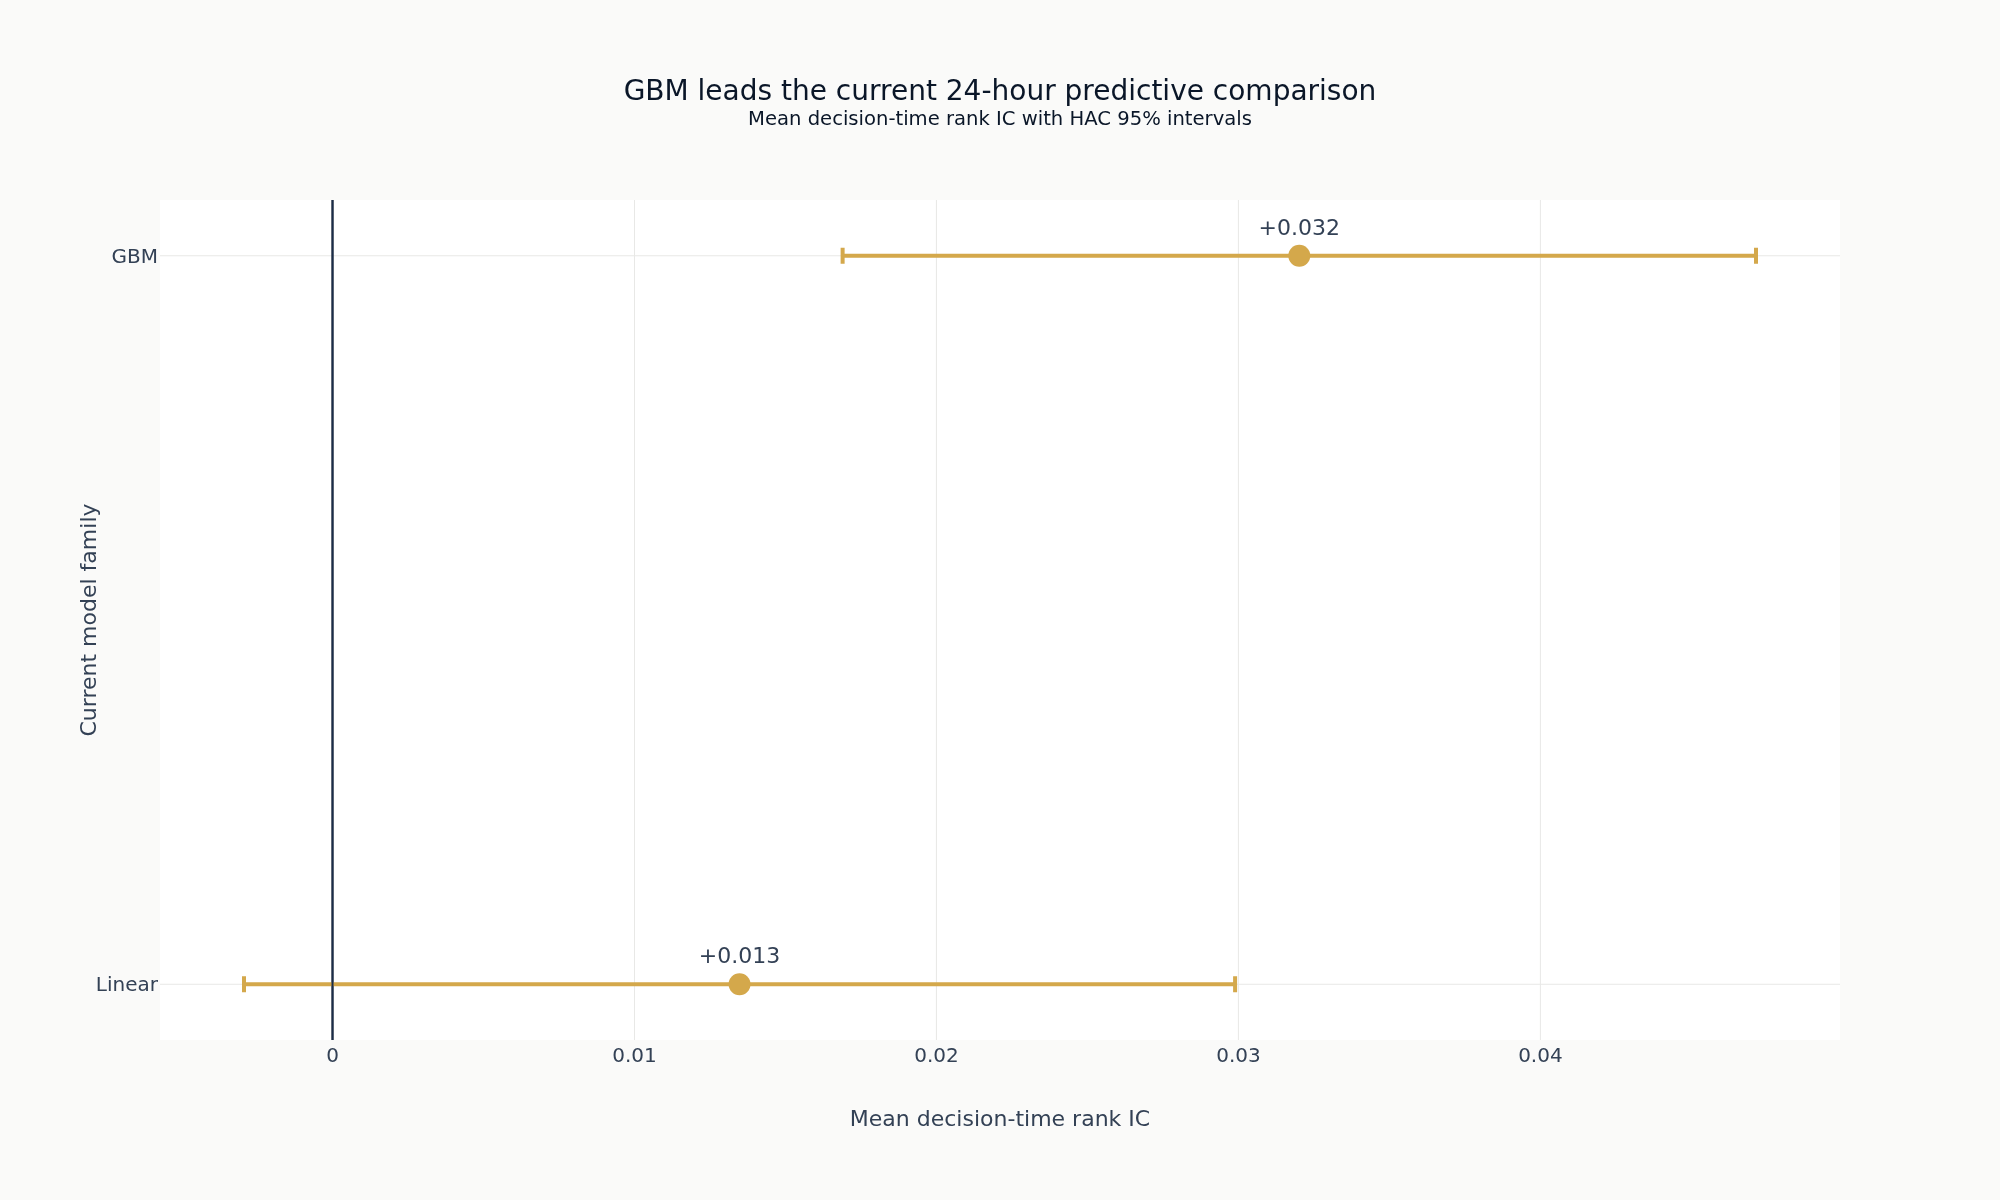

In [15]:
fig = go.Figure(
    go.Scatter(
        x=comparison["ic"],
        y=[{"gbm": "GBM", "linear": "Linear"}[value] for value in comparison["family"]],
        mode="markers+text",
        text=[f"{value:+.3f}" for value in comparison["ic"]],
        textposition="top center",
        marker={"size": 11, "color": COLORS["amber"]},
        error_x={
            "type": "data",
            "symmetric": False,
            "array": (comparison["ci_hi"] - comparison["ic"]).to_list(),
            "arrayminus": (comparison["ic"] - comparison["ci_lo"]).to_list(),
        },
    )
)
fig.add_vline(x=0, line_width=1, line_color=COLORS["slate"])
fig.update_layout(
    title={
        "text": "GBM leads the current 24-hour predictive comparison"
        "<br><sup>Mean decision-time rank IC with HAC 95% intervals</sup>"
    },
    xaxis_title="Mean decision-time rank IC",
    yaxis={"title": "Current model family", "autorange": "reversed"},
    showlegend=False,
)
fig.show()

## Freeze the single current carrier

Predictive IC does not select the strategy. The prescribed validation funnel ranks completed
strategy backtests, and its cross-stage label cohort fixes one carrier before holdout.

In [16]:
def _current_carrier() -> dict:
    """Load and validate the single current cross-stage 24-hour carrier."""
    query = """
        SELECT c.leader_hash, c.k_variants, c.dsr_er, c.dsr_er_pvalue,
               b.stage, b.prediction_hash, b.spec_json,
               m.sharpe, m.sharpe_ci95_lo, m.sharpe_ci95_hi,
               m.sortino, m.total_return, m.max_drawdown,
               t.family, t.config_name, t.label, p.split
        FROM cohort_metrics c
        JOIN backtest_runs b ON b.backtest_hash = c.leader_hash
        JOIN backtest_metrics m USING (backtest_hash)
        JOIN prediction_sets p USING (prediction_hash)
        JOIN training_runs t USING (training_hash)
        WHERE c.cohort_type = 'label' AND c.label = ?
    """
    with sqlite3.connect(f"file:{CURRENT_REGISTRY}?mode=ro", uri=True) as connection:
        connection.row_factory = sqlite3.Row
        row = connection.execute(query, (PRIMARY_LABEL,)).fetchone()
    if row is None:
        raise RuntimeError("The current 24-hour carrier cohort is missing")
    carrier = dict(row)
    identity = {
        "backtest_hash": carrier["leader_hash"],
        "prediction_hash": carrier["prediction_hash"],
        "family": carrier["family"],
        "config_name": carrier["config_name"],
        "stage": carrier["stage"],
    }
    if identity != EXPECTED_CARRIER:
        raise RuntimeError(f"The fixed current carrier changed: {identity}")
    if carrier["label"] != PRIMARY_LABEL or carrier["split"] != "validation":
        raise RuntimeError("The current carrier is not a 24-hour validation artifact")
    strategy = json.loads(carrier["spec_json"])["strategy"]
    if strategy["signal"] != {
        "long_short": True,
        "method": "quintile_long_short",
        "n_quantiles": 5,
        "top_k": 20,
    } or strategy["risk"] != {
        "name": "time_exit_10",
        "position_rules": [{"bars": 10, "type": "time_exit"}],
    }:
        raise RuntimeError("The fixed current carrier strategy changed")
    return carrier

In [17]:
carrier = _current_carrier()
carrier_summary = pl.DataFrame(
    {
        "backtest_hash": [carrier["leader_hash"]],
        "model": [f"{carrier['family']}/{carrier['config_name']}"],
        "prediction_hash": [carrier["prediction_hash"]],
        "risk_rule": ["time_exit_10"],
        "validation_sharpe": [carrier["sharpe"]],
        "sharpe_ci95_lo": [carrier["sharpe_ci95_lo"]],
        "sharpe_ci95_hi": [carrier["sharpe_ci95_hi"]],
        "total_return": [carrier["total_return"]],
        "max_drawdown": [carrier["max_drawdown"]],
        "k_variants": [carrier["k_variants"]],
        "dsr_er_pvalue": [carrier["dsr_er_pvalue"]],
    }
)
print(carrier_summary)

display(
    Markdown(
        f"The current validation funnel fixes **{carrier['leader_hash']}** as the single 24-hour "
        f"carrier: **{carrier['family']}/{carrier['config_name']}**, top-20, with a 10-bar time "
        f"exit. Validation Sharpe is **{carrier['sharpe']:+.3f} "
        f"[{carrier['sharpe_ci95_lo']:+.3f}, {carrier['sharpe_ci95_hi']:+.3f}]**. The "
        f"effective-rank DSR p-value is **{carrier['dsr_er_pvalue']:.3f}** across "
        f"**{carrier['k_variants']}** variants, so selection uncertainty tempers the positive "
        "point estimate. At this pre-holdout boundary, no holdout result had been observed."
    )
)

shape: (1, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ backtest_ ┆ model     ┆ predictio ┆ risk_rule ┆ … ┆ total_ret ┆ max_drawd ┆ k_variant ┆ dsr_er_p │
│ hash      ┆ ---       ┆ n_hash    ┆ ---       ┆   ┆ urn       ┆ own       ┆ s         ┆ value    │
│ ---       ┆ str       ┆ ---       ┆ str       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆           ┆ str       ┆           ┆   ┆ f64       ┆ f64       ┆ i64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ e56dd4ed5 ┆ linear/ri ┆ 53599526d ┆ time_exit ┆ … ┆ 3.065512  ┆ -0.376513 ┆ 257       ┆ 0.105429 │
│ e10       ┆ dge_a10.0 ┆ 2aa       ┆ _10       ┆   ┆           ┆           ┆           ┆          │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘


The current validation funnel fixes **e56dd4ed5e10** as the single 24-hour carrier: **linear/ridge_a10.0**, top-20, with a 10-bar time exit. Validation Sharpe is **+1.626 [+0.183, +3.062]**. The effective-rank DSR p-value is **0.105** across **257** variants, so selection uncertainty tempers the positive point estimate. No holdout result has been observed.

## Pre-holdout publication boundary

GBM leads predictive IC, while the prescribed strategy funnel selects Ridge after mapping scores
into trades, costs, and risk rules. Those are different objectives, not conflicting rankings.
This executed section fixed the carrier before the one-time holdout evaluation.

In [18]:
handoff = pl.DataFrame(
    {
        "surface": ["Current v3.1 24-hour carrier"],
        "establishes": ["Model comparison, validation strategy, cost, risk, and cohort result"],
        "does_not_establish": ["Holdout performance"],
        "state": ["Carrier fixed; holdout sealed"],
    }
)
print(handoff)

current_md5_after = _md5(CURRENT_REGISTRY)
if current_md5_after != current_md5_before:
    raise RuntimeError("Strategy analysis mutated the current registry")

print(f"Current registry unchanged: {current_md5_after}")
print(f"Fixed carrier before holdout: {carrier['leader_hash']}")
print("PASS current-only 24-hour strategy-analysis boundary")

shape: (1, 4)
┌───────────────────────────────┬───────────────────┬─────────────────────┬────────────────────────┐
│ surface                       ┆ establishes       ┆ does_not_establish  ┆ state                  │
│ ---                           ┆ ---               ┆ ---                 ┆ ---                    │
│ str                           ┆ str               ┆ str                 ┆ str                    │
╞═══════════════════════════════╪═══════════════════╪═════════════════════╪════════════════════════╡
│ Current v3.1 24-hour carrier  ┆ Model comparison, ┆ Holdout performance ┆ Carrier fixed; holdout │
│                               ┆ validation s…     ┆                     ┆ sealed                 │
└───────────────────────────────┴───────────────────┴─────────────────────┴────────────────────────┘
Current registry unchanged: 465f1cff82be197ea55b6e1e0145d3cf
Fixed carrier before holdout: e56dd4ed5e10
PASS current-only 24-hour strategy-analysis boundary


## Final current-lineage conclusion

The single authorized holdout evaluation used the fixed validation carrier `e56dd4ed5e10`
without testing another model, label, allocation, cost, or risk configuration. It produced
holdout prediction `db01160096af` and backtest `741abbfe4f77`.

The validation edge did not survive the 2024-2025 holdout. Holdout IC was **-0.0189**, with a
HAC 95% interval of **[-0.0348, -0.0031]**. The fixed strategy returned **-54.2%**, with a Sharpe
ratio of **-0.448** and a 95% interval of **[-1.488, 0.649]**; maximum drawdown was **-68.8%**.
These results replace the positive validation result as the final current-lineage economic
conclusion. The holdout failure is accepted as evidence of regime deterioration, not a reason to
reselect or test alternatives.